In [1]:
import requests as r
import pandas as pd
import time as t
import matplotlib.pyplot as plt
import numpy as np

In [2]:
de_bz_data = pd.read_csv("./BiddingZones/PL_BZ.csv")
de_we_data = pd.read_csv("./Weatherdata/PL_Wetter.csv")

In [3]:
de_bz_data["timestamp"] = pd.to_datetime(de_bz_data["timestamp"], utc=True)
de_we_data["time"] = pd.to_datetime(de_we_data["time"], utc=True)

In [4]:
de_bz_data.columns = de_bz_data.columns.str.replace("values.", "", regex=False)
de_bz_data["date"] = de_bz_data["timestamp"].dt.date

de_we_data["date"] = de_we_data["time"].dt.date

In [5]:
de_bz_data = de_bz_data[de_bz_data["timestamp"].dt.year >= 2023]
de_we_data = de_we_data[de_we_data["time"].dt.year >= 2023]

In [6]:
de_bz_agg = (
    de_bz_data
    .groupby("date")["day_ahead_price"]
    .agg(
        price_mean="mean",
        price_std="std",
        price_min="min",
        price_max="max"
    )
    .reset_index()
)

de_we_agg = (
    de_we_data
    .groupby("date")
    .agg({
        "temperature_2m_max": "mean",
        "precipitation_sum": "mean",
        "shortwave_radiation_sum": "mean",
        "wind_speed_10m_mean": "mean",
        "soil_moisture_28_to_100cm_mean": "mean"
    })
    .reset_index()
)

In [7]:
de_daily = pd.merge(
    de_we_agg,
    de_bz_agg,
    on="date",
    how="inner"
)

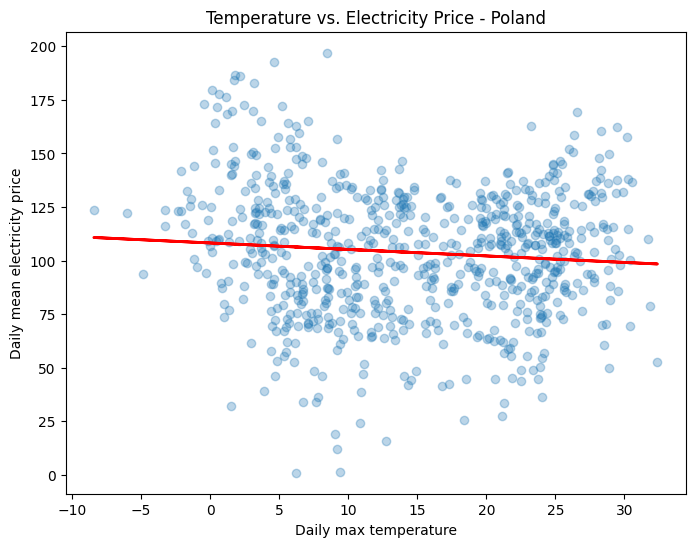

In [10]:
x = de_daily["temperature_2m_max"]
y = de_daily["price_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)
plt.xlabel("Daily max temperature")
plt.ylabel("Daily mean electricity price")
plt.title("Temperature vs. Electricity Price - Poland")

plt.show()

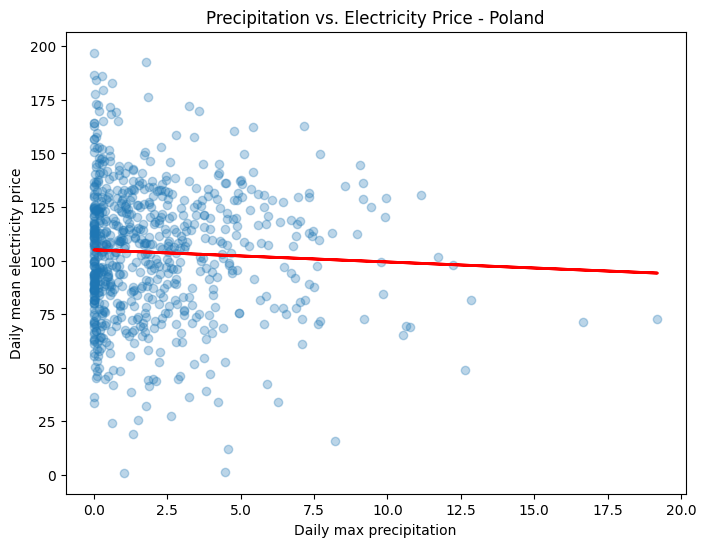

In [9]:
x = de_daily["precipitation_sum"]
y = de_daily["price_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)
plt.xlabel("Daily max precipitation")
plt.ylabel("Daily mean electricity price")
plt.title("Precipitation vs. Electricity Price - Poland")

plt.show()

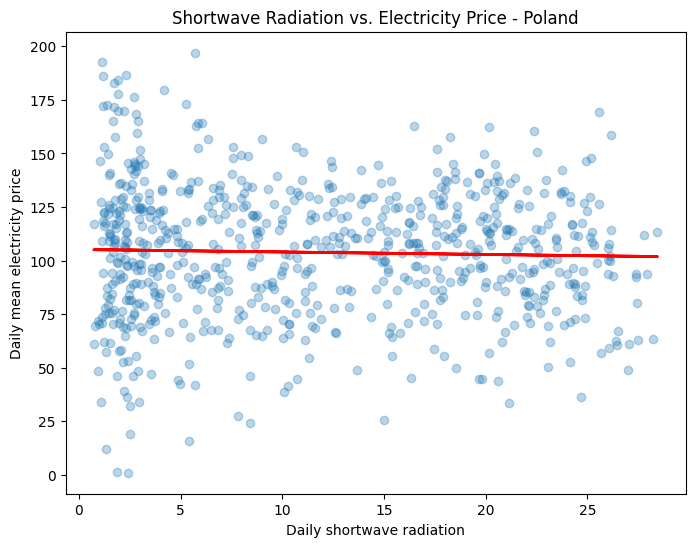

In [11]:
x = de_daily["shortwave_radiation_sum"]
y = de_daily["price_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)
plt.xlabel("Daily shortwave radiation")
plt.ylabel("Daily mean electricity price")
plt.title("Shortwave Radiation vs. Electricity Price - Poland")

plt.show()

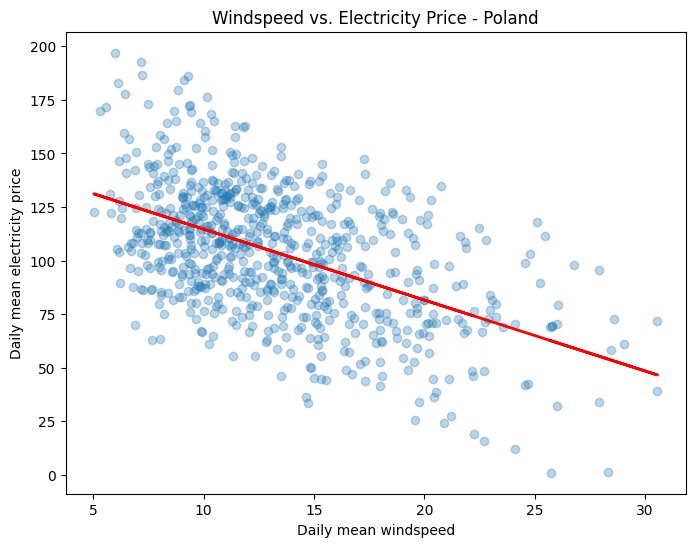

In [12]:
x = de_daily["wind_speed_10m_mean"]
y = de_daily["price_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)

plt.xlabel("Daily mean windspeed")
plt.ylabel("Daily mean electricity price")
plt.title("Windspeed vs. Electricity Price - Poland")

plt.show()

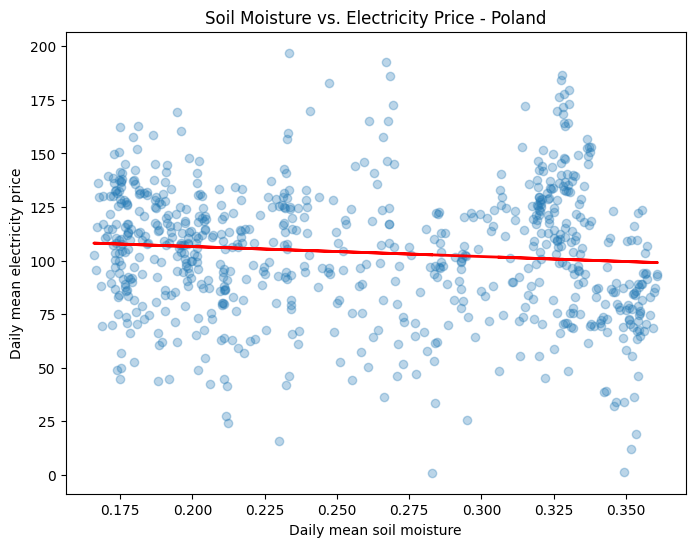

In [13]:
x = de_daily["soil_moisture_28_to_100cm_mean"]
y = de_daily["price_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)

plt.xlabel("Daily mean soil moisture")
plt.ylabel("Daily mean electricity price")
plt.title("Soil Moisture vs. Electricity Price - Poland")

plt.show()